## Imports and setup

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from matplotlib.colors import LinearSegmentedColormap

from meli.evaluation import psi, single_feature_auc, wilson_interval

In [54]:
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
LEGIT_COLOR, FRAUD_COLOR = "#2a78d6", "#eb6834"

### Objetivos:
1. **Estabelecer a baseline** - avaliar a performance preditiva do modelo vigente (Incumbent) a partir dos scores do dataset, justificando quais métricas são mais adequadas para um problema de fraude desbalanceado e por quê. *(Case 1a)*
2. **Treinar um modelo desafiante (Challenger)** capaz de substituir o modelo vigente na discriminação entre transações fraudulentas e legítimas:
    - justificar as técnicas de pré-processamento e o algoritmo escolhidos; *(Case 2a)*
    - comparar os dois modelos no mesmo período de teste (out-of-time), com as mesmas métricas e intervalos de confiança. *(Case 2b)*
3. **Definir o ponto de corte que maximiza o lucro** - considerando comissão de 10% sobre cada transação legítima aprovada e perda de 100% do valor de cada fraude aprovada. *(Case 2c)*

## Step 1 - EDA

In [55]:
df  =  pd.read_csv(  'https://hr-projects-assets-prod.s3.amazonaws.com/3st1g8gm56o/ed953178414189325c980dc1a9214b97/data.csv'  ) 

In [56]:
df.head()

,a,b,c,d,e,f,g,h,i,j,k,l,m,n,o,p,fecha,monto,score,fraude
0,4,0.7685,94436.24,20.0,0.444828,1.0,BR,5,Máquininha Corta Barba Cabelo Peito Perna Pelo...,cat_8d714cd,0.883598,240.0,102.0,1,NaN,N,2020-03-27 11:51:16,5.64,66,0
1,4,0.7550,9258.50,1.0,0.000000,33.0,BR,0,Avental Descartavel Manga Longa - 50 Un. Tnt ...,cat_64b574b,0.376019,4008.0,0.0,1,Y,N,2020-04-15 19:58:08,124.71,72,0
2,4,0.7455,242549.09,3.0,0.000000,19.0,AR,23,Bicicleta Mountain Fire Bird Rodado 29 Alumini...,cat_e9110c5,0.516368,1779.0,77.0,1,NaN,N,2020-03-25 18:13:38,339.32,95,0
3,4,0.7631,18923.90,50.0,0.482385,18.0,BR,23,Caneta Delineador Carimbo Olho Gatinho Longo 2...,cat_d06e653,0.154036,1704.0,1147.0,1,NaN,Y,2020-04-16 16:03:10,3.54,2,0
4,2,0.7315,5728.68,15.0,0.000000,1.0,BR,2,Resident Evil Operation Raccoon City Ps3,cat_6c4cfdc,0.855798,1025.0,150.0,1,NaN,N,2020-04-02 10:24:45,3.53,76,0


In [57]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   a       150000 non-null  int64  
 1   b       137016 non-null  float64
 2   c       137016 non-null  float64
 3   d       149635 non-null  float64
 4   e       150000 non-null  float64
 5   f       149989 non-null  float64
 6   g       149806 non-null  str    
 7   h       150000 non-null  int64  
 8   i       150000 non-null  str    
 9   j       150000 non-null  str    
 10  k       150000 non-null  float64
 11  l       149989 non-null  float64
 12  m       149635 non-null  float64
 13  n       150000 non-null  int64  
 14  o       41143 non-null   str    
 15  p       150000 non-null  str    
 16  fecha   150000 non-null  str    
 17  monto   150000 non-null  float64
 18  score   150000 non-null  int64  
 19  fraude  150000 non-null  int64  
dtypes: float64(9), int64(5), str(6)
memory usage: 22.9 MB


In [58]:
df.select_dtypes(include=["int64", "float64"]).describe()

,a,b,c,d,e,f,h,k,l,m,n,monto,score,fraude
count,150000.000000,137016.000000,1.370160e+05,149635.000000,150000.000000,149989.000000,150000.000000,150000.000000,149989.000000,149635.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,3.705407,0.728115,2.604451e+05,21.677669,0.220641,51.169352,14.193513,0.497532,2305.409403,299.969579,0.902353,43.523134,48.066240,0.050000
std,0.753206,0.132943,8.464361e+05,20.062146,2.434995,709.472904,14.161216,0.288348,1712.379601,321.075806,0.296837,91.557888,28.995122,0.217946
min,1.000000,0.000000,1.600000e-01,0.000000,0.000000,-5.000000,0.000000,0.000004,0.000000,0.000000,0.000000,0.020000,0.000000,0.000000
25%,4.000000,0.678400,9.679915e+03,2.000000,0.000000,1.000000,3.000000,0.246819,910.000000,42.000000,1.000000,9.380000,23.000000,0.000000
50%,4.000000,0.755500,4.371165e+04,14.000000,0.104875,8.000000,9.000000,0.495990,1937.000000,193.000000,1.000000,20.610000,48.000000,0.000000
75%,4.000000,0.806500,1.454436e+05,50.000000,0.282938,33.000000,21.000000,0.746508,3445.000000,459.000000,1.000000,40.692500,73.000000,0.000000
max,4.000000,1.000000,1.387874e+07,50.000000,833.333333,145274.000000,58.000000,0.999995,7544.000000,2225.000000,1.000000,3696.350000,100.000000,1.000000


#### Check target distribution

In [60]:
df["fraude"].value_counts()

fraude
0    142500
1      7500
Name: count, dtype: int64

In [61]:
proportions = df["fraude"].value_counts(normalize=True) * 100
print(f"Transações não fraudulentas: {proportions.get(0, 0):.2f}%\nFraudes: {proportions.get(1, 0):.2f}%")

Transações não fraudulentas: 95.00%
Fraudes: 5.00%


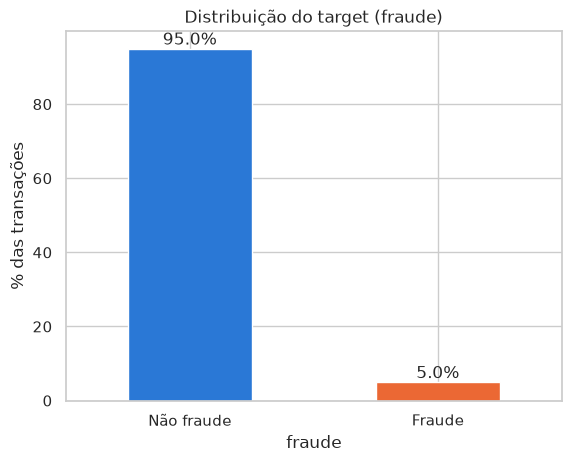

In [46]:
ax = proportions.plot(kind="bar", color=[LEGIT_COLOR, FRAUD_COLOR])
ax.bar_label(ax.containers[0], fmt="%.1f%%")
ax.set_xticklabels(["Não fraude", "Fraude"], rotation=0)
ax.set(ylabel="% das transações", title="Distribuição do target (fraude)")
plt.show()

### Null Checks

In [62]:
df.isnull().sum()

a              0
b          12984
c          12984
d            365
e              0
f             11
g            194
h              0
i              0
j              0
k              0
l             11
m            365
n              0
o         108857
p              0
fecha          0
monto          0
score          0
fraude         0
dtype: int64

#### Nulos: taxa de fraude quando o valor é nulo vs preenchido
A quantidade de nulos sozinha não decide se uma coluna sai. O que importa é se o nulo diz algo sobre fraude: se a taxa muda muito entre nulo e preenchido, o nulo é informativo e vira sinal, em vez de ser imputado ou descartado.

In [58]:
null_cols = df.columns[df.isnull().any()]

null_table = pd.DataFrame({
    "% nulos": df[null_cols].isnull().mean() * 100,
    "fraude se nulo": {c: df.loc[df[c].isnull(), "fraude"].mean() * 100 for c in null_cols},
    "fraude não nulo": {c: df.loc[df[c].notnull(), "fraude"].mean() * 100 for c in null_cols},
})

null_table.sort_values("% nulos", ascending=False).round(2)

,% nulos,fraude se nulo,fraude não nulo
o,72.57,2.05,12.79
b,8.66,6.38,4.87
c,8.66,6.38,4.87
d,0.24,7.95,4.99
m,0.24,7.95,4.99
g,0.13,7.73,5.00
f,0.01,0.00,5.00
l,0.01,0.00,5.00


## Análise de Target (fraude)

### Distribuição de fraude por semana

In [63]:
df["fecha"] = pd.to_datetime(df["fecha"])

# 2. Group by week (W-MON sets the week ending on Monday) and aggregate
fraude_semanal = df.groupby(pd.Grouper(key="fecha", freq="W-MON")).agg(
    total_monto=("monto", "sum"),
    avg_score=("score", "mean"),
    total_fraudes=("fraude", "sum"),
    total_transacciones=("fraude", "count")
)

print(fraude_semanal.head())

            total_monto  avg_score  total_fraudes  total_transacciones
fecha                                                                 
2020-03-09    328305.23  51.100271            321                 7011
2020-03-16   1165245.41  51.181900           1167                24552
2020-03-23   1176084.05  51.451646           1169                24993
2020-03-30    779462.20  50.722406           1094                18437
2020-04-06    754021.76  45.736521           1039                18677


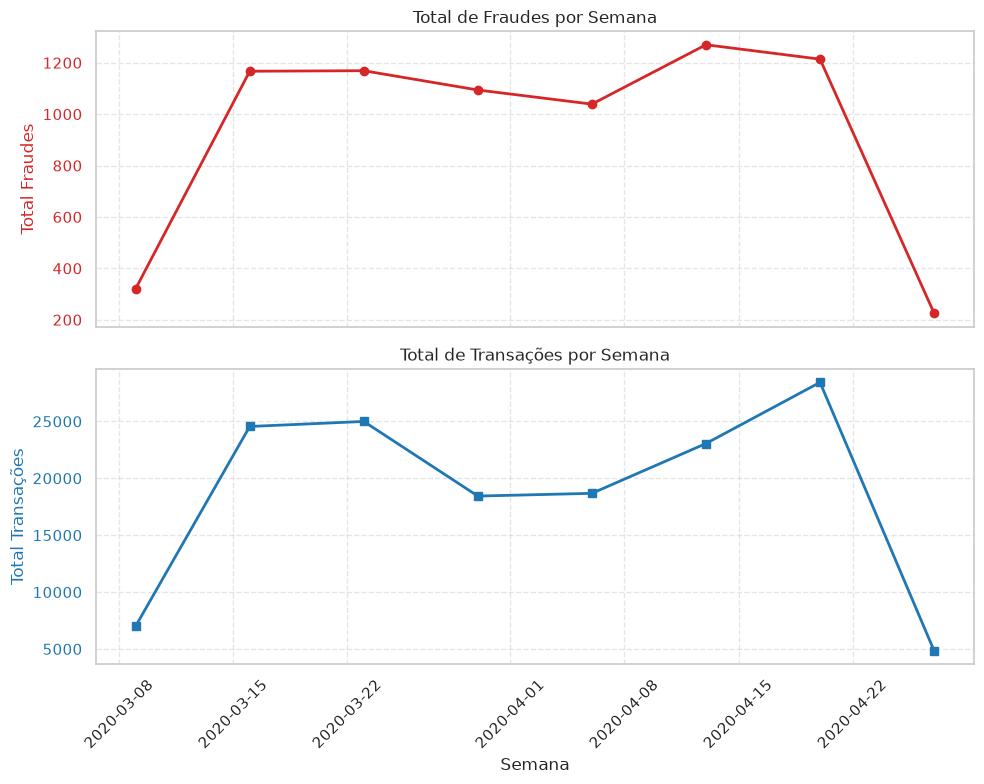

In [73]:
import matplotlib.pyplot as plt

# Create a figure with 2 rows and 1 column
# sharex=True links the x-axis so you only need week labels on the bottom graph
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), sharex=True)

# Top graph: Weekly Frauds
ax1.plot(fraude_semanal.index, fraude_semanal['total_fraudes'], color='tab:red', marker='o', linewidth=2)
ax1.set_ylabel('Total Fraudes', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')
ax1.set_title('Total de Fraudes por Semana')
ax1.grid(True, linestyle='--', alpha=0.5)

# Bottom graph: Overall Transactions
ax2.plot(fraude_semanal.index, fraude_semanal['total_transacciones'], color='tab:blue', marker='s', linewidth=2)
ax2.set_xlabel('Semana')
ax2.set_ylabel('Total Transações', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')
ax2.set_title('Total de Transações por Semana')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, linestyle='--', alpha=0.5)

# Adjust layout so labels don't overlap
fig.tight_layout()
plt.show()

#### Distribuição de valor: fraude vs não fraude observando o valor da transação (monto)

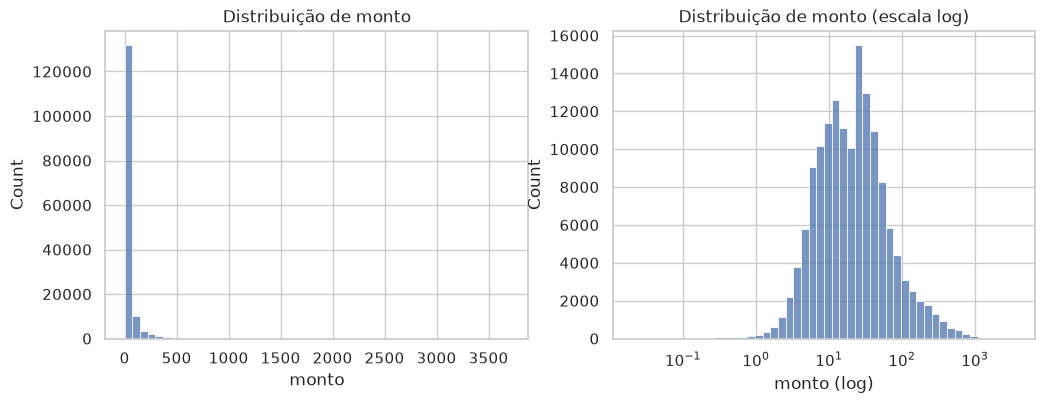

count    150000.00
mean         43.52
std          91.56
min           0.02
25%           9.38
50%          20.61
75%          40.69
max        3696.35
Name: monto, dtype: float64

In [53]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["monto"], bins=50, ax=ax1)
ax1.set(title="Distribuição de monto", xlabel="monto")

sns.histplot(df["monto"], bins=50, log_scale=True, ax=ax2)
ax2.set(title="Distribuição de monto (escala log)", xlabel="monto (log)")

plt.show()

df["monto"].describe().round(2)

`monto` é muito assimétrico (média de ~43, mediana de ~20 e máximo ~3.700), então usamos escala log. Podemos ver que tem-se uma calda longa em que majoritariamente os valores de transação estão concentrados à esquerda do historgrama de distribuição em escala comum. 

No eixo log, cada marca multiplica o valor por 10. A maior parte das transações fica entre 10 e 40 (mediana ≈ 20). As duas classes se sobrepõem nessa faixa, mas acima de ~100 a curva de fraude fica acima da de não fraude: as fraudes se concentram nos valores altos, o que explica elas serem 5% das transações e 8,4% do valor total."

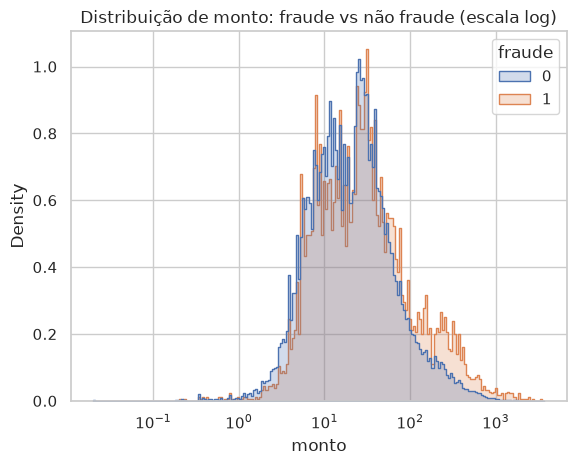

,count,mean,std,min,50%,95%,99%,max
fraude,,,,,,,,
0,142500.0,41.97,85.71,0.02,20.18,151.10,397.66,3696.35
1,7500.0,72.97,164.84,0.21,25.87,313.66,736.72,3424.81


In [54]:
sns.histplot(data=df, x="monto", hue="fraude", log_scale=True,
             stat="density", common_norm=False, element="step")
plt.title("Distribuição de monto: fraude vs não fraude (escala log)")
plt.show()

df.groupby("fraude")["monto"].describe(percentiles=[0.5, 0.95, 0.99]).round(2)

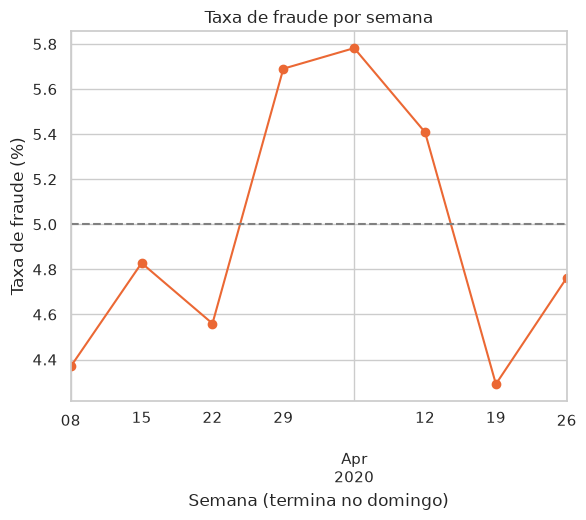

,transacoes,taxa_fraude
fecha,,
2020-03-08,2838,4.37
2020-03-15,24523,4.83
2020-03-22,25199,4.56
2020-03-29,20069,5.69
2020-04-05,17434,5.78
2020-04-12,24443,5.41
2020-04-19,25332,4.29
2020-04-26,10162,4.76


In [51]:
df["fecha"] = pd.to_datetime(df["fecha"])

weekly = df.groupby(pd.Grouper(key="fecha", freq="W-SUN")).agg(
    transacoes=("fraude", "size"),
    taxa_fraude=("fraude", "mean"),
)
weekly["taxa_fraude"] *= 100

ax = weekly["taxa_fraude"].plot(marker="o", color=FRAUD_COLOR)
ax.axhline(df["fraude"].mean() * 100, color="gray", linestyle="--")  # média geral (5%)
ax.set(title="Taxa de fraude por semana", xlabel="Semana (termina no domingo)", ylabel="Taxa de fraude (%)")
plt.show()

weekly.round(2)

#### Participação da fraude: por quantidade vs por `monto`
Fraudes são 5% das transações, mas pesam mais no valor total, porque se concentram em valores mais altos. É o valor que define o Profit, não a quantidade.

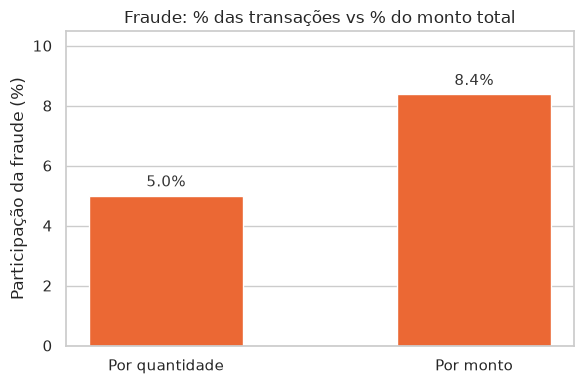

Por quantidade    5.00
Por monto         8.38
dtype: float64

In [66]:
is_fraud = df["fraude"] == 1
fraud_share = pd.Series({
    "Por quantidade": is_fraud.mean(),
    "Por monto": df.loc[is_fraud, "monto"].sum() / df["monto"].sum(),
}) * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(fraud_share.index, fraud_share.values, color=FRAUD_COLOR, width=0.5)
ax.bar_label(bars, labels=[f"{v:.1f}%" for v in fraud_share], padding=4, fontsize=11, color="#333333")
ax.set(ylabel="Participação da fraude (%)", ylim=(0, fraud_share.max() * 1.25),
       title="Fraude: % das transações vs % do monto total")
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

fraud_share.round(2)

### Taxa de fraude das variáveis numéricas
Cada variável é dividida em decis, e para cada faixa calculamos a taxa de fraude.
- Linha plana perto da média (5%) = sem sinal.
- Linha subindo ou descendo = a variável separa fraude de não fraude.
- Formato em U ou salto = sinal não linear, que um modelo de árvore captura melhor que uma regressão logística.

O título traz a AUC da variável sozinha (0,5 = sem sinal). Linhas com nulo ficam de fora; o nulo foi analisado na tabela de nulos.

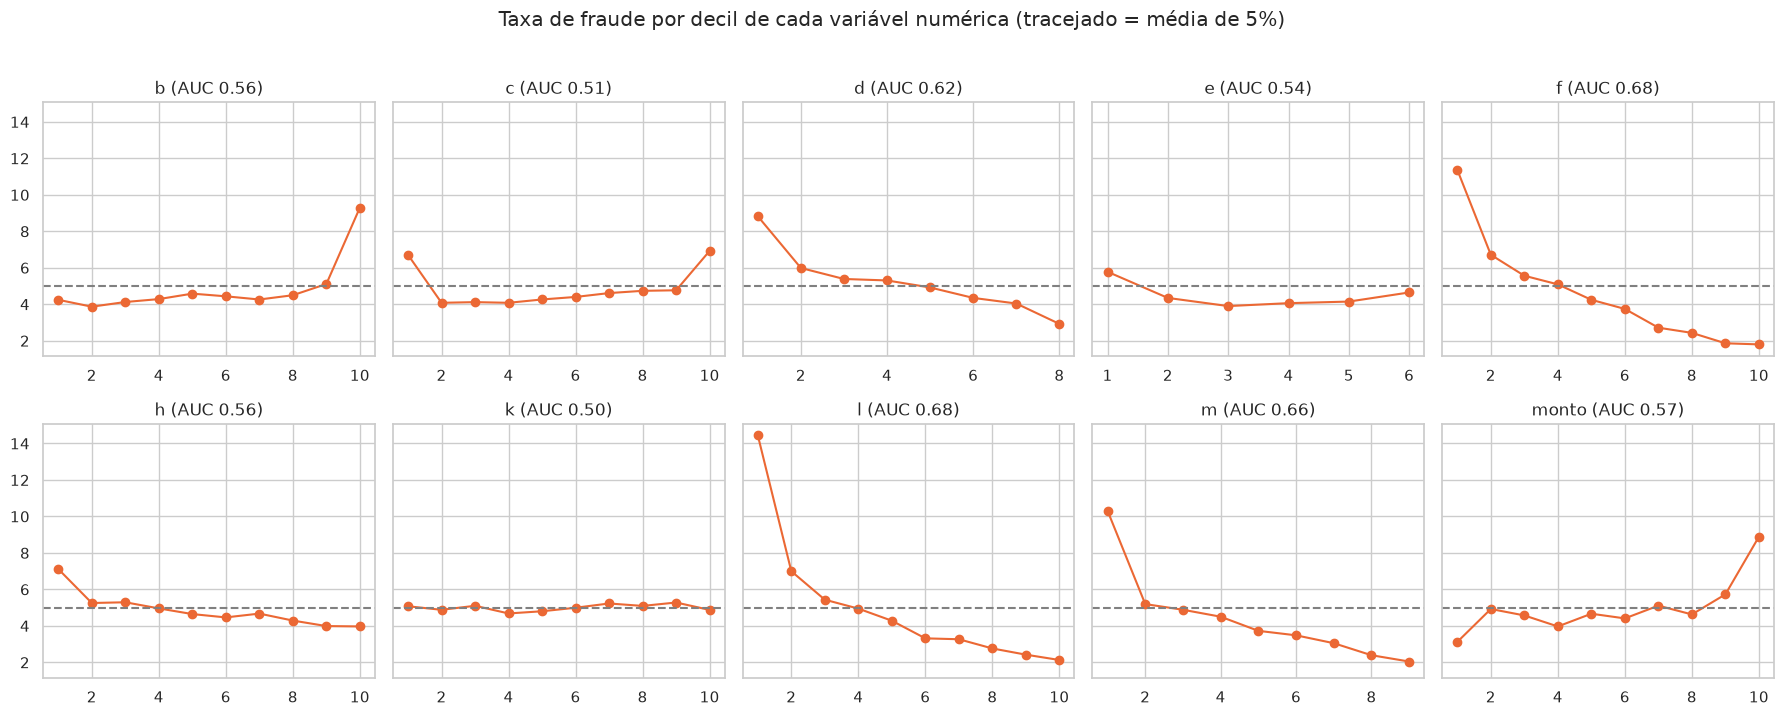

In [63]:
from sklearn.metrics import roc_auc_score

numeric_cols = ["b", "c", "d", "e", "f", "h", "k", "l", "m", "monto"]
fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharey=True)

for ax, col in zip(axes.flatten(), numeric_cols):
    data = df[[col, "fraude"]].dropna()

    # Taxa de fraude em cada decil da variável
    rate = data.groupby(pd.qcut(data[col], 10, duplicates="drop"), observed=True)["fraude"].mean() * 100
    auc = roc_auc_score(data["fraude"], data[col])

    ax.plot(range(1, len(rate) + 1), rate.values, marker="o", color=FRAUD_COLOR)
    ax.axhline(5, color="gray", linestyle="--")  # média geral
    ax.set_title(f"{col} (AUC {max(auc, 1 - auc):.2f})")

fig.suptitle("Taxa de fraude por decil de cada variável numérica (tracejado = média de 5%)", y=1.02)
plt.tight_layout()
plt.show()

### Taxa de fraude das variáveis categóricas
Para cada nível da variável, a taxa de fraude. O `n` de cada nível aparece no eixo: uma taxa alta com poucas transações não é confiável.
- Nulo vira um nível próprio (`nulo`), porque ele pode ser informativo (caso de `o`).
- Países com menos de 200 transações vão para `OUTROS`; sem isso, países com 1–3 transações aparecem com 100% de fraude.
- `j` (8.324 categorias) fica de fora: tem níveis demais para um gráfico e será tratada no feature engineering.

   mean    size
a              
1  9.42    4195
2  7.78   14378
3  9.06    2848
4  4.46  128579


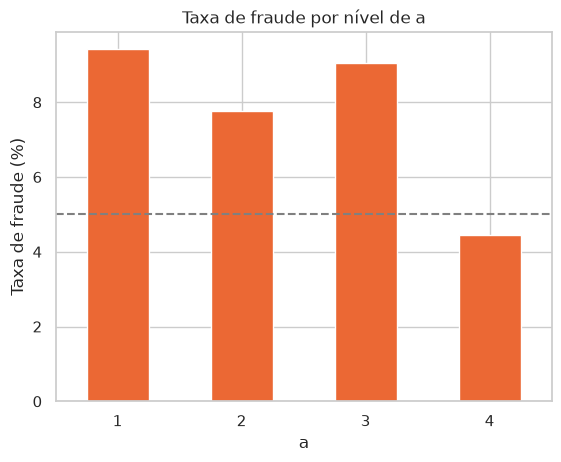

        mean    size
g                   
AR      3.69   31964
BR      5.52  111628
MX      1.27     236
OUTROS  7.32     574
SE      4.19     358
US      3.08    2273
UY      0.98    2967


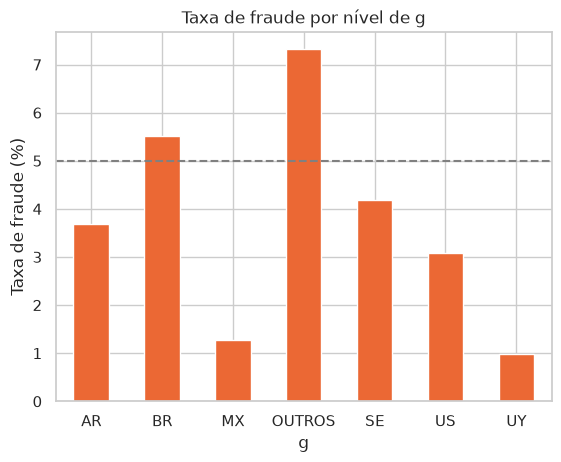

    mean    size
n               
0  16.11   14647
1   3.80  135353


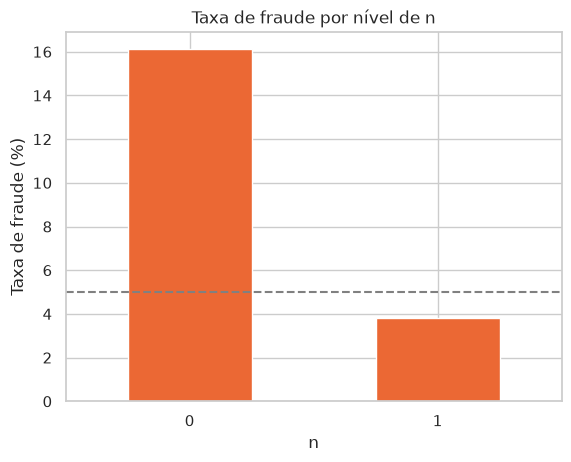

       mean    size
o                  
N     21.75   17052
Y      6.45   24091
nulo   2.05  108857


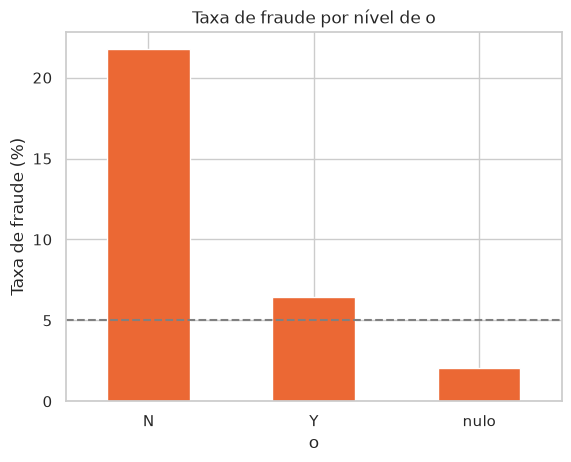

   mean   size
p             
N  7.60  66871
Y  2.91  83129


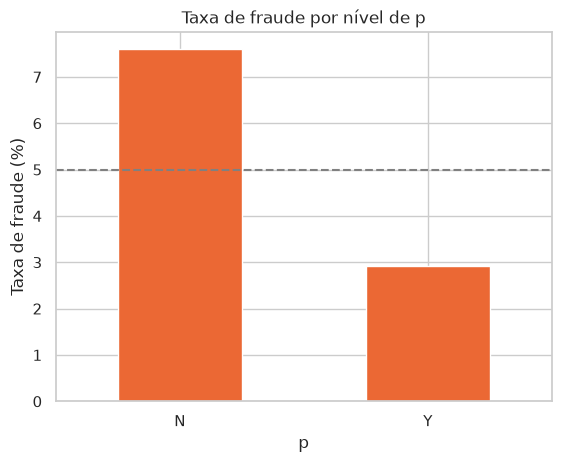

In [52]:
for col in ["a", "g", "n", "o", "p"]:
    levels = df[col].fillna("nulo").astype(str)

    # Países com poucas transações vão para OUTROS
    rare = levels.map(levels.value_counts()) < 200
    levels[rare] = "OUTROS"

    table = df.groupby(levels)["fraude"].agg(["mean", "size"])
    table["mean"] *= 100
    print(table.round(2))

    ax = table["mean"].plot(kind="bar", color=FRAUD_COLOR)
    ax.axhline(df["fraude"].mean() * 100, color="gray", linestyle="--")  # média geral (5%)
    ax.set(title=f"Taxa de fraude por nível de {col}", xlabel=col, ylabel="Taxa de fraude (%)")
    plt.xticks(rotation=0)
    plt.show()

### Resumo por coluna
Uma linha por coluna: tipo, % de nulos, como tratar o nulo, AUC individual (só numéricas) e a decisão.
Regra: manter por padrão; remover só o que vaza informação, identifica a linha ou não tem sinal.

In [ ]:
from sklearn.metrics import roc_auc_score

summary = pd.DataFrame([
    # coluna,      tipo,          decisão
    ("k",          "numérica",    "drop: única por linha, sem sinal"),
    ("score",      "Incumbent",   "fora do modelo, só avaliação"),
    ("f",          "numérica",    "manter (melhor sinal)"),
    ("l",          "numérica",    "manter (melhor sinal)"),
    ("m",          "numérica",    "manter"),
    ("d",          "numérica",    "manter"),
    ("b",          "numérica",    "drop"),
    ("c",          "numérica",    "manter"),
    ("e",          "numérica",    "manter"),
    ("h",          "numérica",    "manter"),
    ("monto",      "numérica",    "manter"),
    ("a",          "categórica",  "manter"),
    ("n",          "categórica",  "manter"),
    ("o",          "categórica",  "manter; nulo vira categoria"),
    ("p",          "categórica",  "manter"),
    ("g",          "categórica",  "manter; países raros em OUTROS"),
    ("j",          "categórica",  "transformar: frequência da categoria"),
    ("i",          "texto",       "transformar: tamanho do título"),
    ("fecha",      "data",        "transformar: hora e dia da semana"),
], columns=["coluna", "tipo", "decisao"]).set_index("coluna")

summary["pct_nulos"] = (df[summary.index].isnull().mean() * 100).round(2)
summary

,tipo,decisao,pct_nulos
coluna,,,
k,numérica,"drop: única por linha, sem sinal",0.00
score,Incumbent,"fora do modelo, só avaliação",0.00
f,numérica,manter (melhor sinal),0.01
l,numérica,manter (melhor sinal),0.01
m,numérica,manter,0.24
d,numérica,manter,0.24
b,numérica,manter + flag de nulo,8.66
c,numérica,manter,8.66
e,numérica,manter,0.00
